In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# Jupyter runs this from this folder; the figures go to results/figures/.
os.makedirs('results/figures', exist_ok=True)

# Same look as the paper's other figures: white panels, thin black bar edges,
# black 95% CI error bars, grey dashed chance line, frameless legend.
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'axes.labelsize': 13, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150,
})

# Grounded = blue, erroneous = red, as in the paper's text and multi-judge trajectories figure.
# Pre-debate is the light shade, post-debate the dark one: the blue and red pairs of the
# paper's accuracy-by-protocol figure.
GROUP_PRE   = {'mainstream': '#a6c8e0', 'skeptical': '#f4a3a3'}
GROUP_POST  = {'mainstream': '#1f77b4', 'skeptical': '#d62728'}
GROUP_TITLE = {'mainstream': 'Grounded judges', 'skeptical': 'Erroneous judges'}
LEGEND_LIGHT, LEGEND_DARK = '#dddddd', '#777777'   # neutral swatches for pre/post in legends

BAR_KW = dict(edgecolor='black', linewidth=0.6, capsize=4,
              error_kw={'lw': 1.0, 'ecolor': 'black'}, zorder=3)
CHANCE_KW      = dict(color='#aaaaaa', ls='--', lw=1, zorder=0)
CLAUDE_PRE_KW  = dict(color='#444444', ls=':',  lw=1.5, zorder=2)
CLAUDE_POST_KW = dict(color='#000000', ls='-.', lw=1.2, zorder=2)
DELTA_COLOR = '#444444'

# Per-model colours avoid blue and red, which encode the two groups.
MODEL_COLOR  = {'Qwen2.5-7B': '#9467bd', 'Llama-3.1-8B': '#2ca02c',
                'Gemma-3-4B': '#ff7f0e', 'Claude': '#555555'}
MODEL_LABELS = {'Qwen2.5-7B': 'Qwen2.5-7B', 'Llama-3.1-8B': 'Llama-3.1-8B',
                'Gemma-3-4B': 'Gemma-3-4B', 'Claude': 'Claude Sonnet 4'}
XROT = dict(rotation=20, ha='right')   # x tick labels, as in the paper's bar figures
MODELS_OPEN  = ['Qwen2.5-7B', 'Llama-3.1-8B', 'Gemma-3-4B']
MODELS_ALL   = ['Qwen2.5-7B', 'Llama-3.1-8B', 'Gemma-3-4B', 'Claude']

def wilson(k, n, alpha=0.05):
    """Wilson score 95% CI for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan)
    z = stats.norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centre - half, centre + half)

def prop(df, group, cond, dtype, col):
    """(proportion, CI low, CI high) of `col` for one group / condition / ordering."""
    s = df[(df.group == group) & (df.condition == cond) & (df.debate_type == dtype)]
    k, n = int(s[col].sum()), len(s)
    lo, hi = wilson(k, n)
    return (k / n if n else np.nan, lo, hi)

def bars_ci(ax, xs, vals, width, color):
    """Bars with Wilson 95% CI error bars; `vals` is a list of prop() tuples."""
    p  = np.array([v[0] for v in vals])
    lo = np.array([v[1] for v in vals]); hi = np.array([v[2] for v in vals])
    ax.bar(xs, p, width, color=color, yerr=[p - lo, hi - p], **BAR_KW)

def annotate_delta(ax, first, second, xs):
    """Δ (second − first, pp) above the higher CI of each pair, as in the paper."""
    for a, b, xi in zip(first, second, xs):
        if not (np.isfinite(a[0]) and np.isfinite(b[0])):
            continue
        top = max(a[2], b[2])
        ax.text(xi, top + 0.025, f"Δ={(b[0] - a[0]) * 100:+.1f} pp",
                ha='center', va='bottom', fontsize=10, color=DELTA_COLOR, zorder=4,
                bbox=dict(facecolor='white', edgecolor='none', pad=0.8))

def accuracy_axis(ax):
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.axhline(0.5, **CHANCE_KW)

def save(name):
    for ext in ['pdf', 'png']:
        plt.savefig(f'results/figures/{name}.{ext}', bbox_inches='tight', dpi=180)
    plt.show(); print(f'→ results/figures/{name}.pdf')

In [2]:
import os, numpy as np, pandas as pd
from load_results import load_evaluations

raw = {
    'Qwen2.5-7B':   load_evaluations('Qwen2.5-7B-Instruct'),
    'Llama-3.1-8B': load_evaluations('Llama-3.1-8B-Instruct'),
    'Gemma-3-4B':   load_evaluations('gemma-3-4b-it'),
}
for df in raw.values():
    df['pre_correct']  = df['pre_statement_ground_truth_alignment'].astype(int)
    df['post_correct'] = df['post_statement_ground_truth_alignment'].astype(int)

# Claude Sonnet 4 reference: per-claim C3 (GPB system prompt) evaluations from the
# collaborators' temperature-0 run -- the run behind the paper's Sec. 5.2 numbers.
CLAUDE_DIR = '../debate_experiment_one_judge_con_persona/results/sonnet_temp_0'
_parts = []
for group, dtype, order in [('mainstream', 'normal',   'original'),
                            ('skeptical',  'normal',   'original'),
                            ('mainstream', 'inverted', 'inverted'),
                            ('skeptical',  'inverted', 'inverted')]:
    df = pd.read_csv(os.path.join(CLAUDE_DIR, f'evaluations_{group}_{order}_sonnet_temp_0.csv'))
    df['group'], df['debate_type'], df['condition'] = group, dtype, 'C3'
    df['pre_correct']  = df['pre_statement_ground_truth_alignment'].astype(int)
    df['post_correct'] = df['post_statement_ground_truth_alignment'].astype(int)
    _parts.append(df)
claude = pd.concat(_parts, ignore_index=True)

def acc(df, group, cond, dtype, col):
    s = df[(df.group == group) & (df.condition == cond) & (df.debate_type == dtype)]
    return s[col].mean() * 100 if len(s) else np.nan

print('Loaded from results/:')
for name, df in raw.items():
    print(f'  {name:14s}  {len(df):5d} rows · groups={sorted(df.group.unique())} · '
          f'conds={sorted(df.condition.unique())} · types={sorted(df.debate_type.unique())}')
print(f'  Claude          {len(claude):5d} rows from {CLAUDE_DIR} (C3, normal+inverted)')


Loaded from results/:
  Qwen2.5-7B       2340 rows · groups=['mainstream', 'skeptical'] · conds=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] · types=['inverted', 'normal']
  Llama-3.1-8B     2340 rows · groups=['mainstream', 'skeptical'] · conds=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] · types=['inverted', 'normal']
  Gemma-3-4B       2340 rows · groups=['mainstream', 'skeptical'] · conds=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'] · types=['inverted', 'normal']
  Claude            396 rows from ../debate_experiment_one_judge_con_persona/results/sonnet_temp_0 (C3, normal+inverted)


---
## Figure 1 — Prompting shifts pre-debate priors (place after experimental design table)

Pre-debate accuracy only, across C1 / C3 / C5. Validates the prompting-based method.

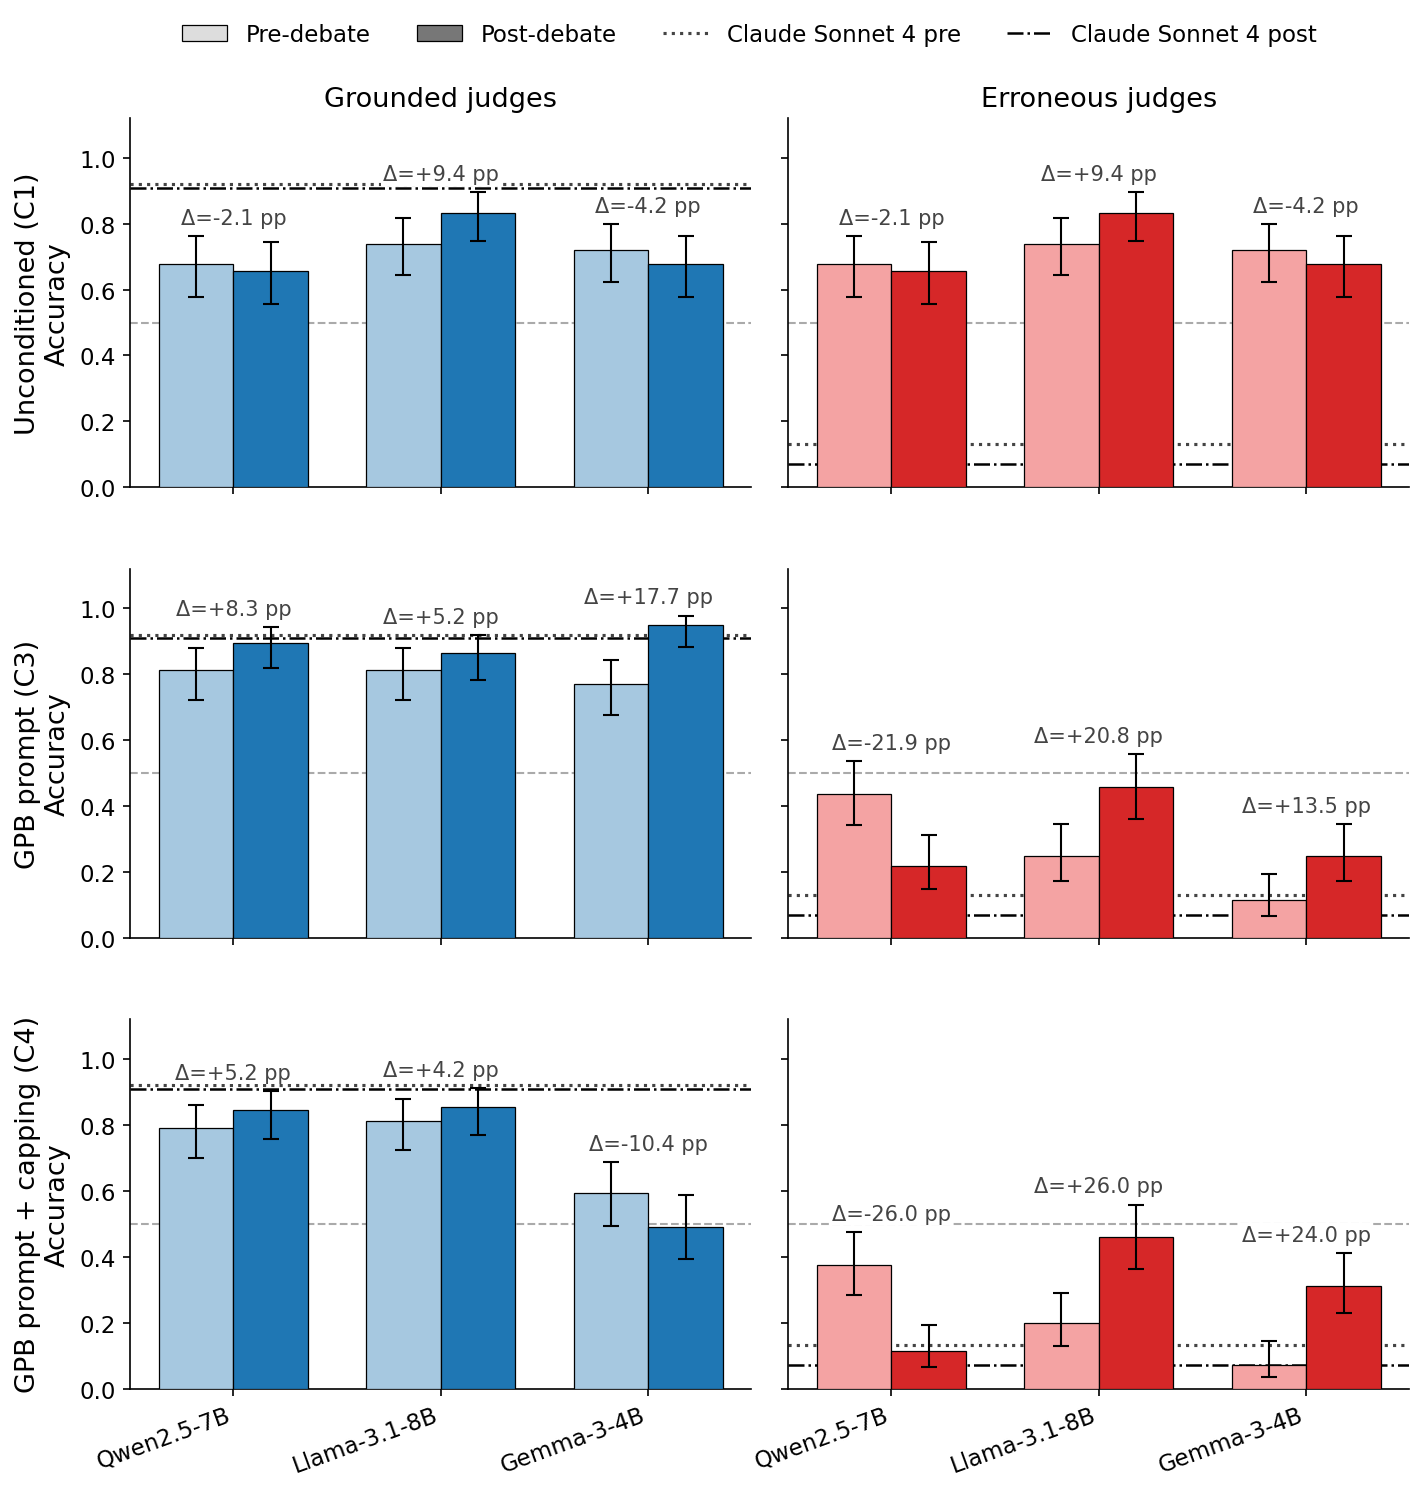

→ results/figures/fig_main.pdf


In [3]:
# Fig 1: pre/post accuracy across C1, C3, C4 — per model, both groups (original ordering)
rows = [('C1', 'Unconditioned (C1)'), ('C3', 'GPB prompt (C3)'), ('C4', 'GPB prompt + capping (C4)')]
x, w = np.arange(len(MODELS_OPEN)), 0.36

fig, axes = plt.subplots(3, 2, figsize=(11, 11), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0.22, wspace=0.06)

for row_i, (cond, row_label) in enumerate(rows):
    for col_i, group in enumerate(['mainstream', 'skeptical']):
        ax = axes[row_i][col_i]
        pre  = [prop(raw[m], group, cond, 'normal', 'pre_correct')  for m in MODELS_OPEN]
        post = [prop(raw[m], group, cond, 'normal', 'post_correct') for m in MODELS_OPEN]
        bars_ci(ax, x - w/2, pre,  w, GROUP_PRE[group])
        bars_ci(ax, x + w/2, post, w, GROUP_POST[group])
        annotate_delta(ax, pre, post, x)
        accuracy_axis(ax)

        ax.axhline(prop(claude, group, 'C3', 'normal', 'pre_correct')[0],  **CLAUDE_PRE_KW)
        ax.axhline(prop(claude, group, 'C3', 'normal', 'post_correct')[0], **CLAUDE_POST_KW)

        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_OPEN], **XROT)
        if row_i == 0:
            ax.set_title(GROUP_TITLE[group])
        if col_i == 0:
            ax.set_ylabel(f'{row_label}\nAccuracy')

handles = [
    mpatches.Patch(facecolor=LEGEND_LIGHT, edgecolor='black', linewidth=0.6, label='Pre-debate'),
    mpatches.Patch(facecolor=LEGEND_DARK,  edgecolor='black', linewidth=0.6, label='Post-debate'),
    plt.Line2D([0], [0], color=CLAUDE_PRE_KW['color'],  ls=':',  lw=1.5, label='Claude Sonnet 4 pre'),
    plt.Line2D([0], [0], color=CLAUDE_POST_KW['color'], ls='-.', lw=1.2, label='Claude Sonnet 4 post'),
]
fig.legend(handles=handles, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.95), frameon=False)
save('fig_main')

---
## Figure 2 — Capping further shifts priors (place immediately after Figure 1)

Within each condition pair, solid = no cap, hatched = with cap. Shows the mechanistic intervention adds a further shift on top of the prompt.

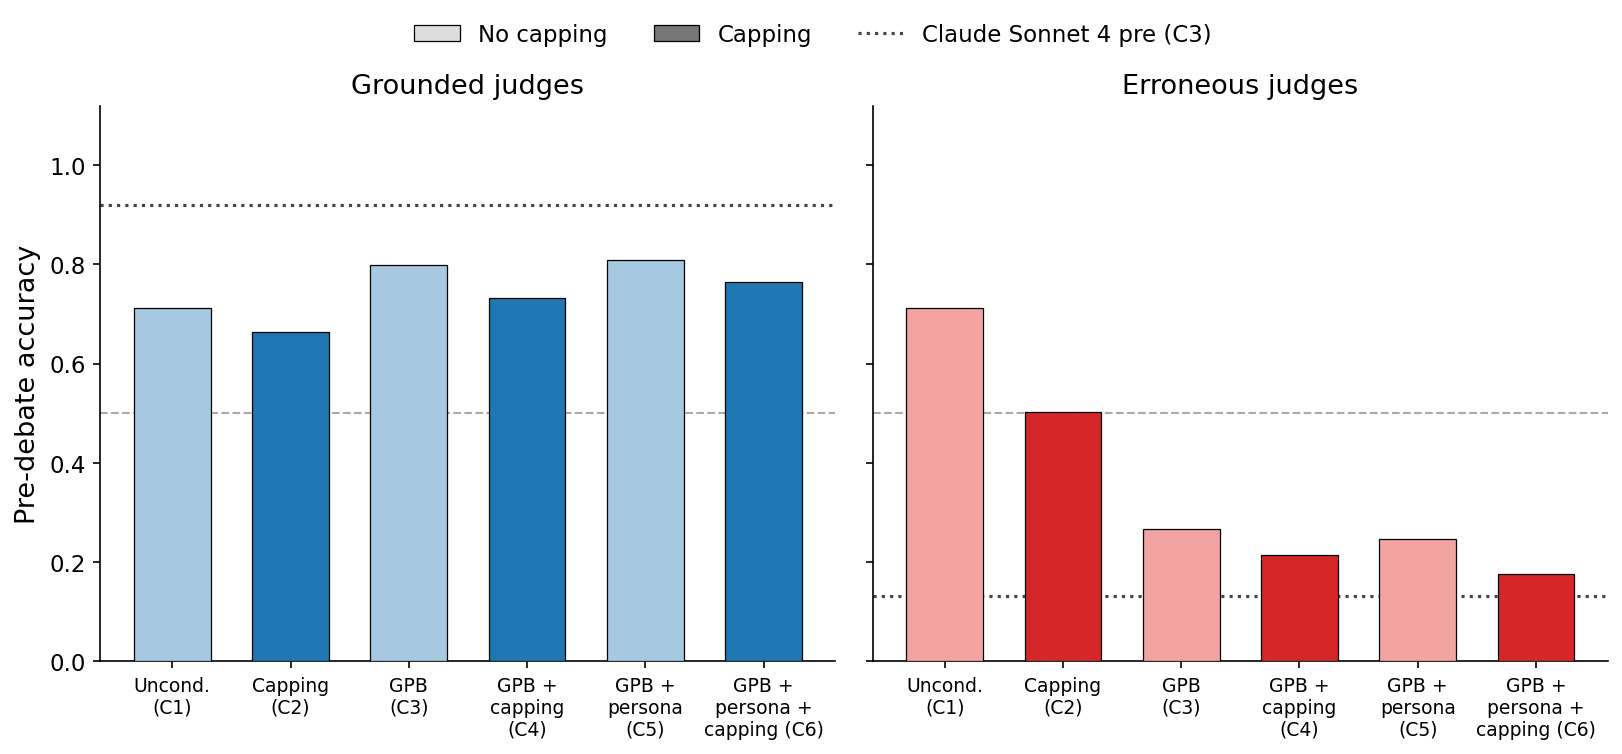

→ results/figures/fig2_cap_prior.pdf


In [4]:
# Fig 2: pre-debate accuracy, all 6 conditions (no cap light, cap dark), mean over the open models
conds  = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
labels = ['Uncond.\n(C1)', 'Capping\n(C2)', 'GPB\n(C3)',
          'GPB +\ncapping\n(C4)', 'GPB +\npersona\n(C5)', 'GPB +\npersona +\ncapping (C6)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    means = [np.mean([prop(raw[m], group, c, 'normal', 'pre_correct')[0] for m in MODELS_OPEN])
             for c in conds]
    colors = [GROUP_PRE[group] if i % 2 == 0 else GROUP_POST[group] for i in range(6)]
    ax.bar(range(6), means, color=colors, width=0.65, edgecolor='black', linewidth=0.6, zorder=3)
    accuracy_axis(ax)
    ax.axhline(prop(claude, group, 'C3', 'normal', 'pre_correct')[0], **CLAUDE_PRE_KW)
    ax.set_xticks(range(6)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(GROUP_TITLE[group])

axes[0].set_ylabel('Pre-debate accuracy')
handles = [
    mpatches.Patch(facecolor=LEGEND_LIGHT, edgecolor='black', linewidth=0.6, label='No capping'),
    mpatches.Patch(facecolor=LEGEND_DARK,  edgecolor='black', linewidth=0.6, label='Capping'),
    plt.Line2D([0], [0], color=CLAUDE_PRE_KW['color'], ls=':', lw=1.5, label='Claude Sonnet 4 pre (C3)'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.06), frameon=False)
plt.tight_layout()
save('fig2_cap_prior')

---
## Figure 3 — Debates shift beliefs in both directions (place at start of Results)

C3 condition, normal debates. Pre (light) vs post (dark) accuracy for all models and Claude.

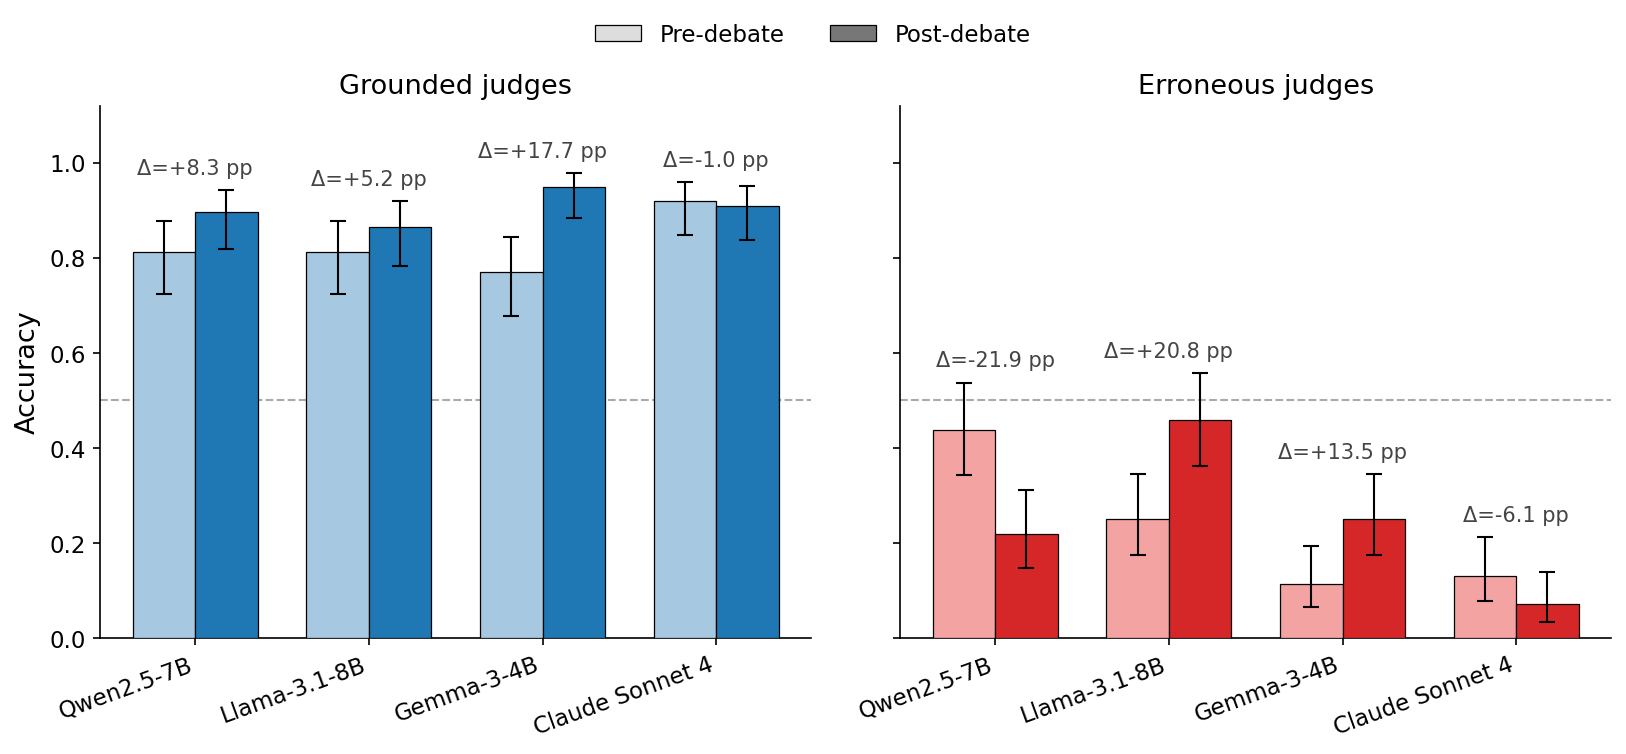

→ results/figures/fig3_pre_post_c3.pdf


In [5]:
all_data = {**raw, 'Claude': claude}

# Fig 3: pre vs post debate accuracy, C3, all models (original ordering)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
x, w = np.arange(len(MODELS_ALL)), 0.36

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    pre  = [prop(all_data[m], group, 'C3', 'normal', 'pre_correct')  for m in MODELS_ALL]
    post = [prop(all_data[m], group, 'C3', 'normal', 'post_correct') for m in MODELS_ALL]
    bars_ci(ax, x - w/2, pre,  w, GROUP_PRE[group])
    bars_ci(ax, x + w/2, post, w, GROUP_POST[group])
    annotate_delta(ax, pre, post, x)
    accuracy_axis(ax)
    ax.set_xticks(x); ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_ALL], **XROT)
    ax.set_title(GROUP_TITLE[group])

axes[0].set_ylabel('Accuracy')
handles = [
    mpatches.Patch(facecolor=LEGEND_LIGHT, edgecolor='black', linewidth=0.6, label='Pre-debate'),
    mpatches.Patch(facecolor=LEGEND_DARK,  edgecolor='black', linewidth=0.6, label='Post-debate'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.06), frameon=False)
plt.tight_layout()
save('fig3_pre_post_c3')

---
## Supplementary: inversion effect and cap delta (not in main text)

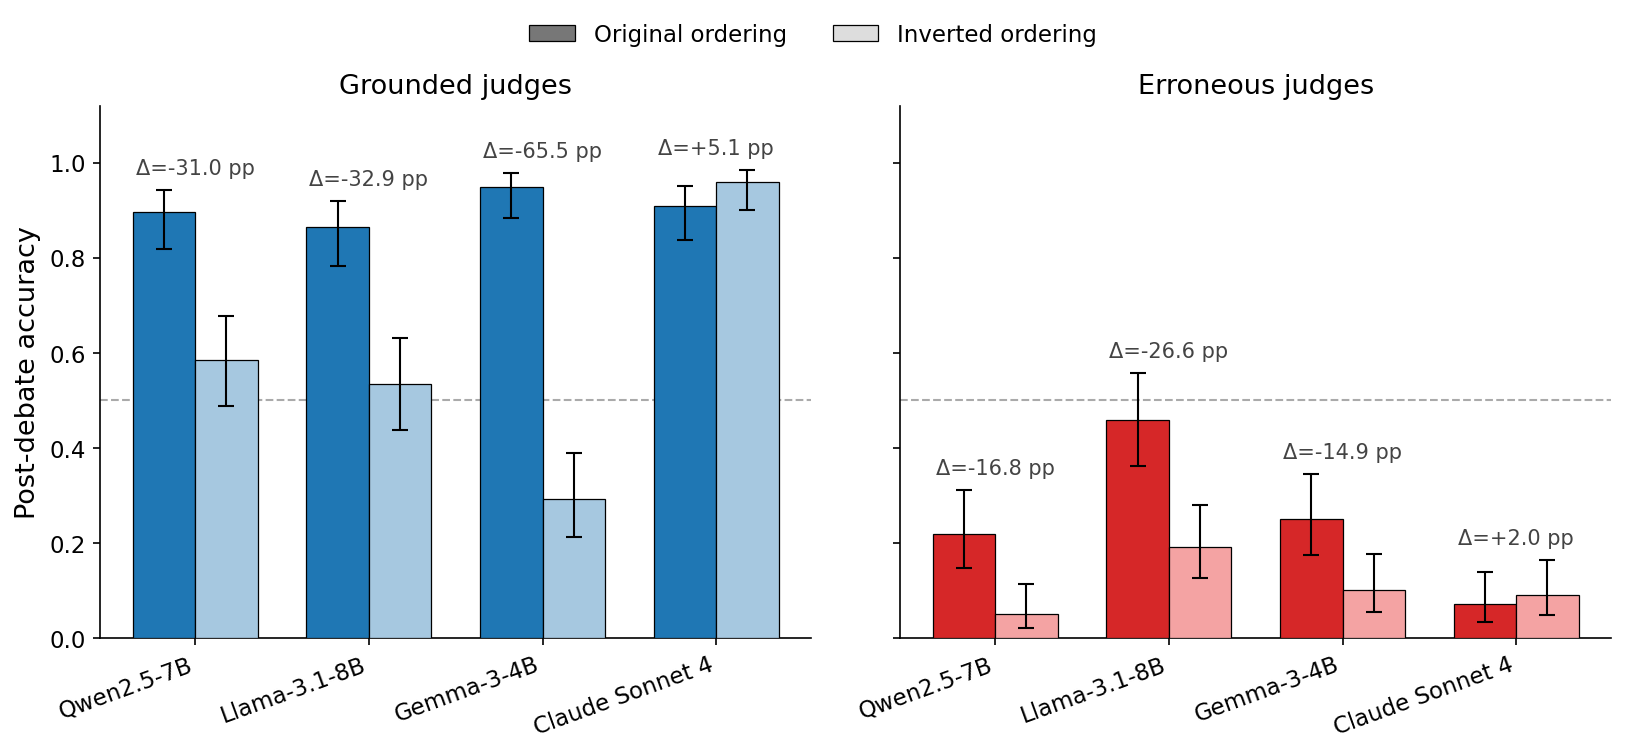

→ results/figures/supp_inversion.pdf


In [6]:
# Inversion effect: original vs inverted ordering, post-debate accuracy, C3
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
x, w = np.arange(len(MODELS_ALL)), 0.36

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    orig = [prop(all_data[m], group, 'C3', 'normal',   'post_correct') for m in MODELS_ALL]
    inv  = [prop(all_data[m], group, 'C3', 'inverted', 'post_correct') for m in MODELS_ALL]
    bars_ci(ax, x - w/2, orig, w, GROUP_POST[group])
    bars_ci(ax, x + w/2, inv,  w, GROUP_PRE[group])
    annotate_delta(ax, orig, inv, x)
    accuracy_axis(ax)
    ax.set_xticks(x); ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_ALL], **XROT)
    ax.set_title(GROUP_TITLE[group])

axes[0].set_ylabel('Post-debate accuracy')
handles = [
    mpatches.Patch(facecolor=LEGEND_DARK,  edgecolor='black', linewidth=0.6, label='Original ordering'),
    mpatches.Patch(facecolor=LEGEND_LIGHT, edgecolor='black', linewidth=0.6, label='Inverted ordering'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.06), frameon=False)
plt.tight_layout()
save('supp_inversion')

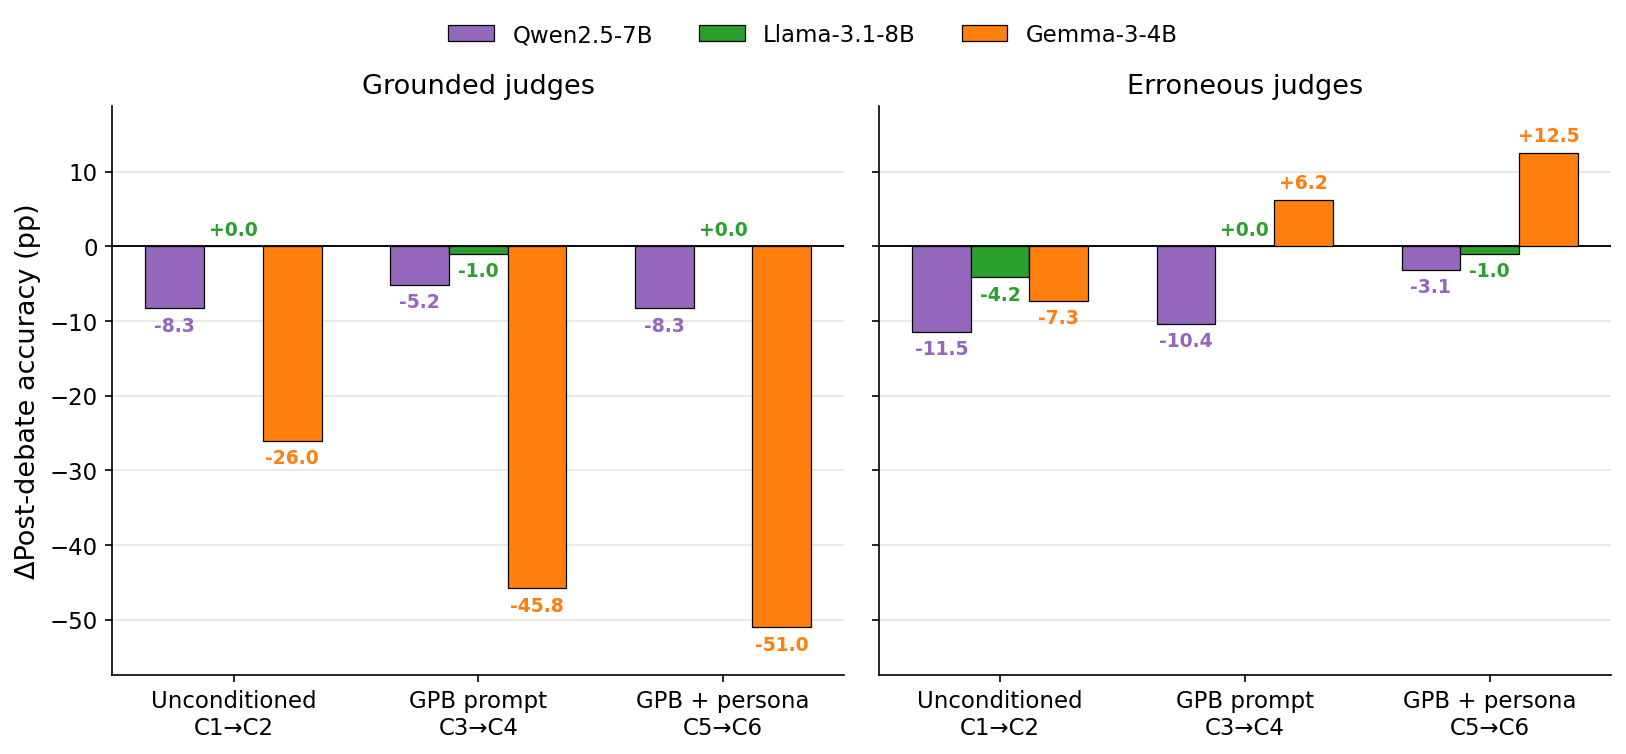

→ results/figures/supp_cap_delta.pdf


In [7]:
PAIRS = [('C1', 'C2', 'Unconditioned\nC1→C2'),
         ('C3', 'C4', 'GPB prompt\nC3→C4'),
         ('C5', 'C6', 'GPB + persona\nC5→C6')]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
x, w = np.arange(len(PAIRS)), 0.24

for ax, group in zip(axes, ['mainstream', 'skeptical']):
    for m_i, model in enumerate(MODELS_OPEN):
        deltas = [(prop(raw[model], group, p[1], 'normal', 'post_correct')[0]
                   - prop(raw[model], group, p[0], 'normal', 'post_correct')[0]) * 100 for p in PAIRS]
        bars = ax.bar(x + (m_i - 1) * w, deltas, w, color=MODEL_COLOR[model],
                      edgecolor='black', linewidth=0.6, zorder=3)
        for bar, val in zip(bars, deltas):
            if np.isfinite(val):
                ax.text(bar.get_x() + bar.get_width() / 2, val + (1.0 if val >= 0 else -1.0),
                        f'{val:+.1f}', ha='center', va='bottom' if val >= 0 else 'top',
                        fontsize=9, fontweight='bold', color=MODEL_COLOR[model])
    ax.axhline(0, color='black', lw=0.9, zorder=2)
    ax.margins(y=0.1)
    ax.grid(axis='y', color='#e5e5e5', lw=0.8, zorder=0)
    ax.set_xticks(x); ax.set_xticklabels([p[2] for p in PAIRS])
    ax.set_title(GROUP_TITLE[group])

axes[0].set_ylabel('ΔPost-debate accuracy (pp)')
handles = [mpatches.Patch(facecolor=MODEL_COLOR[m], edgecolor='black', linewidth=0.6, label=MODEL_LABELS[m])
           for m in MODELS_OPEN]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.06), frameon=False)
plt.tight_layout()
save('supp_cap_delta')

In [8]:
print('C3, normal — pre → post')
for group in ['mainstream','skeptical']:
    print(f'  {group.upper()}')
    for m in MODELS_ALL:
        pre  = acc(all_data[m], group, 'C3', 'normal', 'pre_correct')
        post = acc(all_data[m], group, 'C3', 'normal', 'post_correct')
        print(f'    {MODEL_LABELS[m]:18s}  {pre:.1f}% → {post:.1f}%  ({post-pre:+.1f}pp)')

C3, normal — pre → post
  MAINSTREAM
    Qwen2.5-7B          81.2% → 89.6%  (+8.3pp)
    Llama-3.1-8B        81.2% → 86.5%  (+5.2pp)
    Gemma-3-4B          77.1% → 94.8%  (+17.7pp)
    Claude Sonnet 4     91.9% → 90.9%  (-1.0pp)
  SKEPTICAL
    Qwen2.5-7B          43.8% → 21.9%  (-21.9pp)
    Llama-3.1-8B        25.0% → 45.8%  (+20.8pp)
    Gemma-3-4B          11.5% → 25.0%  (+13.5pp)
    Claude Sonnet 4     13.1% → 7.1%  (-6.1pp)
